In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Lab 9 - Multi-layer Perceptron Forward Pass & Backpropagation

## Part I — Regressão: Boston Housing

Notação de Bishop (PRML): W tem shape **(to, from+1)** — linhas = neurônios destino, colunas = neurônios origem + bias.
O bias ocupa a **coluna 0** (pois `_add_ones` prefixa uma coluna de 1s).

In [2]:
housing_names = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]
boston = pd.read_table("housing.txt", names=housing_names, sep="\s+")

In [3]:
X = boston.values[:,:-1]
y = boston.values[:,-1]

X_train, X_aux, y_train, y_aux = train_test_split(X, y, train_size=0.7, random_state=42)
X_val,  X_test, y_val,  y_test  = train_test_split(X_aux, y_aux, train_size=0.5, random_state=42)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (354, 13), Val: (76, 13), Test: (76, 13)


In [4]:
class ActivationFunction:
    def __init__(self, function, derivative=None):
        self.function = function
        self.derivative = derivative

def sigmoid(a): return 1 / (1 + np.exp(-np.clip(a, -500, 500)))
def sigmoid_prime(a): return sigmoid(a) * (1 - sigmoid(a))

sigmoid_activation = ActivationFunction(sigmoid, sigmoid_prime)

def softmax(a):
    # Numerically stable softmax
    a_shifted = a - a.max(axis=1, keepdims=True)
    exp_a = np.exp(a_shifted)
    return exp_a / exp_a.sum(axis=1, keepdims=True)

def identity(a): return a

In [5]:
class MultilayerPerceptron:
    """
    Notação Bishop (PRML):
      - W[l] tem shape (to, from+1)  →  parâmetro [j, i] = peso do neurônio i (origem) para j (destino)
      - Bias está na coluna 0 (prefixado por _add_ones)
      - Forward:  a = Z @ W.T   (Z: n×from+1, W: to×from+1)
      - Backprop: δ_W = δ.T @ Z / n   (δ: n×to  →  δ.T: to×n  →  to×(from+1))
      - Propagação: δ⁽ˡ⁾ = h'(A⁽ˡ⁾) ⊙ (δ⁽ˡ⁺¹⁾ @ W⁽ˡ⁺¹⁾[:, 1:])  ← remove coluna do bias
    """

    def __init__(self, hidden_activation: ActivationFunction, output_activation, sizes: list):
        self.num_layers = len(sizes) - 1
        self.num_hidden_layers = len(sizes) - 2
        self.sizes = sizes
        self.hidden_activation = hidden_activation.function
        self.hidden_activation_prime = hidden_activation.derivative
        self.output_activation = output_activation
        self.parameters = [np.random.randn(y, x + 1) * 0.1
                           for x, y in zip(sizes[:-1], sizes[1:])]

    def _initialize_parameters(self):
        self.parameters = [np.random.randn(y, x + 1) * 0.1
                           for x, y in zip(self.sizes[:-1], self.sizes[1:])]

    @staticmethod
    def _add_ones(X):
        """Prefixa coluna de 1s (bias) — coluna 0."""
        return np.column_stack((np.ones(X.shape[0]), X))

    def _forward_pass(self, X):
        z = self._add_ones(X)
        Zs = [z]   # Zs[l]: entrada da camada l (com bias), shape (n, from_l+1)
        As = []    # As[l]: pré-ativação da camada oculta l, shape (n, to_l)

        for w in self.parameters[:-1]:
            a = z @ w.T          # (n, from+1) @ (from+1, to) = (n, to)
            As.append(a)
            z = self._add_ones(self.hidden_activation(a))
            Zs.append(z)

        a = z @ self.parameters[-1].T
        y = self.output_activation(a)
        return y, Zs, As

    def _fast_forward_pass(self, X):
        z = self._add_ones(X)
        for w in self.parameters[:-1]:
            z = self._add_ones(self.hidden_activation(z @ w.T))
        return self.output_activation(z @ self.parameters[-1].T)

    @staticmethod
    def _output_derivative(y_prev, target):
        """δ de saída para SSE+identidade ou softmax+cross-entropy: y - t"""
        return y_prev - target

    def fit(self, X_train, y_train, X_val, y_val,
            update_method='mini_batch', batch_size=32,
            lr=0.01, epochs=1, weight_decay=0.0):

        if update_method == 'sgd':   batch_size = 1
        if update_method == 'batch': batch_size = X_train.shape[0]

        n_samples = X_train.shape[0]
        loss_train, loss_val = [], []

        for epoch in range(epochs):
            idx = np.random.permutation(n_samples)
            X_train, y_train = X_train[idx], y_train[idx]

            for start in range(0, n_samples, batch_size):
                Xb = X_train[start:start + batch_size]
                yb = y_train[start:start + batch_size]
                delta_w = self.backpropagation(Xb, yb)

                for i, dw in enumerate(delta_w):
                    if weight_decay > 0:
                        # CORRETO: bias está na coluna 0, não penalizar
                        reg = np.zeros_like(self.parameters[i])
                        reg[:, 1:] = weight_decay * self.parameters[i][:, 1:]
                        dw = dw + reg
                    self.parameters[i] -= lr * dw

            yp_tr = self._fast_forward_pass(X_train)
            yp_va = self._fast_forward_pass(X_val)
            loss_train.append(self.compute_loss(yp_tr, y_train))
            loss_val.append(self.compute_loss(yp_va, y_val))

        return loss_train, loss_val

In [6]:
class MultilayerPerceptronRegression(MultilayerPerceptron):

    def __init__(self, hidden_activation, output_activation, sizes):
        super().__init__(hidden_activation, output_activation, sizes)

    def backpropagation(self, X, y):
        """
        Backprop na notação Bishop:
          δ_W[l] = δ[l].T @ Z[l] / n      shape: (to_l, from_l+1)  ✓
          δ[l]   = h'(A[l]) ⊙ (δ[l+1] @ W[l+1][:, 1:])  ← [:, 1:] remove coluna bias
        """
        n = X.shape[0]
        delta_w = [np.zeros_like(w) for w in self.parameters]

        y_pred, Zs, As = self._forward_pass(X)
        y_enc = y.reshape(-1, 1) if y_pred.shape[1] == 1 else y

        # --- Camada de saída ---
        # delta: (n, 1)   →   delta.T @ Zs[-1]: (1, n) @ (n, from+1) = (1, from+1)  ✓
        delta = self._output_derivative(y_pred, y_enc)
        delta_w[-1] = delta.T @ Zs[-1] / n

        # --- Camadas ocultas (de trás pra frente) ---
        # CORRECAO 1: range vai até -1 (inclui l=0)
        # CORRECAO 2: delta @ W[l+1][:, 1:]  (remove coluna 0 = bias, não linha 0)
        # CORRECAO 3: delta.T @ Zs[l]  (não Zs[l].T @ delta)
        for l in range(self.num_hidden_layers - 1, -1, -1):
            delta = self.hidden_activation_prime(As[l]) * (delta @ self.parameters[l + 1][:, 1:])
            delta_w[l] = delta.T @ Zs[l] / n

        return delta_w

    def predict(self, X):
        y_pred = self._fast_forward_pass(X)
        return y_pred.flatten() if y_pred.shape[1] == 1 else y_pred

    @staticmethod
    def rmse(target, y_prev): return np.sqrt(np.mean((target - y_prev) ** 2))

    def compute_loss(self, y_prev, target): return self.rmse(target, y_prev.flatten())

In [7]:
np.random.seed(0)
MLP_reg = MultilayerPerceptronRegression(sigmoid_activation, identity, [13, 6, 5, 8, 1])
lht, lhv = MLP_reg.fit(X_train, y_train, X_val, y_val,
                        update_method='mini_batch', batch_size=32,
                        lr=0.001, epochs=200, weight_decay=0.001)
print(f'Train RMSE final: {lht[-1]:.4f} | Val RMSE final: {lhv[-1]:.4f}')

Train RMSE final: 9.3777 | Val RMSE final: 8.4012


### Curva de aprendizado — Regressão

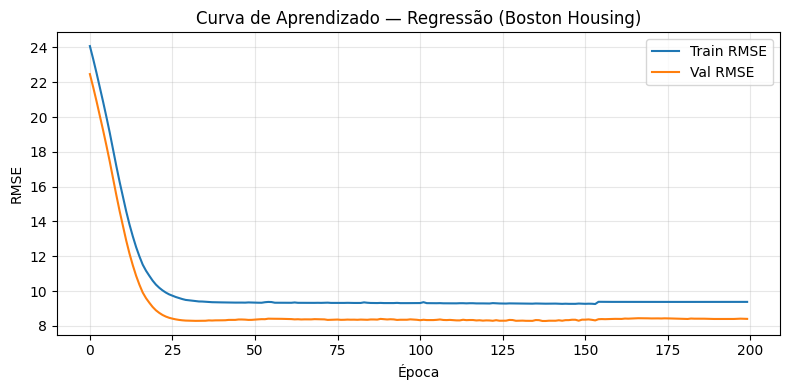

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lht, label='Train RMSE')
ax.plot(lhv, label='Val RMSE')
ax.set_xlabel('Época')
ax.set_ylabel('RMSE')
ax.set_title('Curva de Aprendizado — Regressão (Boston Housing)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Métricas no conjunto de teste — Regressão

=== Avaliação no conjunto de TESTE ===
  RMSE : 9.0747  (erro médio em $1 000)
  MAE  : 6.7517
  R²   : -0.0361  (1.0 = perfeito)


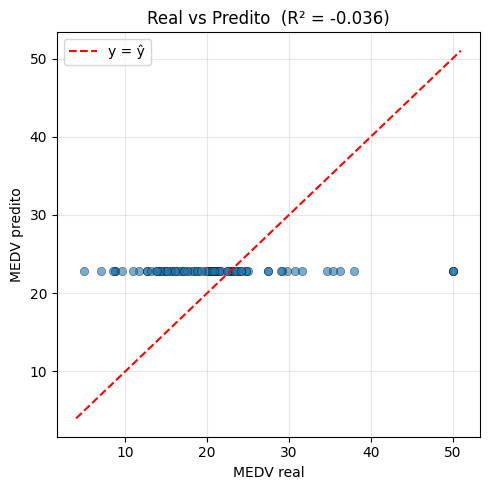

In [9]:
y_pred_test = MLP_reg.predict(X_test)

rmse_test = MLP_reg.rmse(y_test, y_pred_test)
mae_test  = mean_absolute_error(y_test, y_pred_test)
r2_test   = r2_score(y_test, y_pred_test)

print('=== Avaliação no conjunto de TESTE ===')
print(f'  RMSE : {rmse_test:.4f}  (erro médio em $1 000)')
print(f'  MAE  : {mae_test:.4f}')
print(f'  R²   : {r2_test:.4f}  (1.0 = perfeito)')

# Scatter real vs predito
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='k', linewidths=0.4)
lims = [min(y_test.min(), y_pred_test.min()) - 1,
        max(y_test.max(), y_pred_test.max()) + 1]
ax.plot(lims, lims, 'r--', lw=1.5, label='y = ŷ')
ax.set_xlabel('MEDV real')
ax.set_ylabel('MEDV predito')
ax.set_title(f'Real vs Predito  (R² = {r2_test:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part II — Classificação: Digits (sklearn)

Softmax na saída + cross-entropy. Mesma lógica de backprop:
δ_saída = y_pred − y_target (identidade para softmax+CE).

In [10]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler

digits = load_digits()
X = digits.data
y = digits.target
print(f'Dataset: {X.shape}, classes: {np.unique(y)}')

Dataset: (1797, 64), classes: [0 1 2 3 4 5 6 7 8 9]


In [11]:
# CORRECAO: segunda divisão usa X_aux, y_aux (não X, y)
X_train, X_aux, y_train, y_aux = train_test_split(X, y, train_size=0.70, random_state=42)
X_val,  X_test, y_val,  y_test  = train_test_split(X_aux, y_aux, train_size=0.50, random_state=42)

# Normalizar (importante para sigmoid)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (1257, 64), Val: (270, 64), Test: (270, 64)


In [ ]:
class MultilayerPerceptronClassification(MultilayerPerceptron):

    def __init__(self, hidden_activation, output_activation, sizes):
        super().__init__(hidden_activation, output_activation, sizes)
        self.num_classes = sizes[-1]

    @staticmethod
    def _one_hot(y, num_classes):
        Y = np.zeros((len(y), num_classes))
        Y[np.arange(len(y)), y] = 1
        return Y

    @staticmethod
    def _output_derivative(y_prev, target):
        """Gradiente de softmax + cross-entropy = y - t"""
        return y_prev - target

    def backpropagation(self, X, y):
        """
        Mesma derivação do Bishop, generalizada para multi-classe:
          δ_W[l] = δ[l].T @ Z[l] / n
          δ[l]   = h'(A[l]) ⊙ (δ[l+1] @ W[l+1][:, 1:])
        """
        n = X.shape[0]
        delta_w = [np.zeros_like(w) for w in self.parameters]

        y_pred, Zs, As = self._forward_pass(X)
        y_target = self._one_hot(y, self.num_classes) if y.ndim == 1 else y

        # --- Camada de saída ---
        # CORRECAO: delta.T @ Zs[-1]  (não Zs[-1].T @ delta)
        delta = self._output_derivative(y_pred, y_target)   # (n, K)
        delta_w[-1] = delta.T @ Zs[-1] / n                  # (K, from+1)  ✓

        # --- Camadas ocultas (mesma lógica da regressão) ---
        # CORRECAO: range correto + [:, 1:] + orientação certa
        for l in range(self.num_hidden_layers - 1, -1, -1):
            delta = self.hidden_activation_prime(As[l]) * (delta @ self.parameters[l + 1][:, 1:])
            delta_w[l] = delta.T @ Zs[l] / n

        return delta_w

    def predict(self, X):
        return self._fast_forward_pass(X)

    def predict_classes(self, X):
        return np.argmax(self._fast_forward_pass(X), axis=1)

    def cross_entropy(self, target, y_prev):
        t = self._one_hot(target, self.num_classes)
        # Clip para evitar log(0)
        y_prev = np.clip(y_prev, 1e-12, 1.0)
        return -np.sum(t * np.log(y_prev)) / len(target)

    def compute_loss(self, y_prev, target):
        # CORRECAO: ordem correta dos argumentos
        return self.cross_entropy(target, y_prev)

In [13]:
np.random.seed(42)
MLP_clf = MultilayerPerceptronClassification(sigmoid_activation, softmax, [64, 32, 16, 10])

# CORRECAO: passa X_val, y_val corretamente
lht_c, lhv_c = MLP_clf.fit(X_train, y_train, X_val, y_val,
                             update_method='mini_batch', batch_size=32,
                             lr=0.1, epochs=150, weight_decay=1e-3)
print(f'Cross-entropy final — Train: {lht_c[-1]:.4f} | Val: {lhv_c[-1]:.4f}')

Cross-entropy final — Train: 0.3570 | Val: 0.3958


### Curva de aprendizado — Classificação

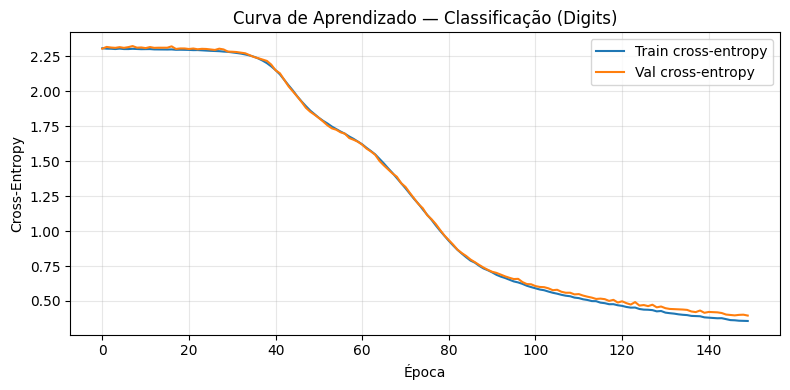

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lht_c, label='Train cross-entropy')
ax.plot(lhv_c, label='Val cross-entropy')
ax.set_xlabel('Época')
ax.set_ylabel('Cross-Entropy')
ax.set_title('Curva de Aprendizado — Classificação (Digits)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Métricas no conjunto de teste — Classificação

=== Avaliação no conjunto de TESTE ===
  Acurácia      : 0.9000  (90.0%)
  Cross-Entropy : 0.4236


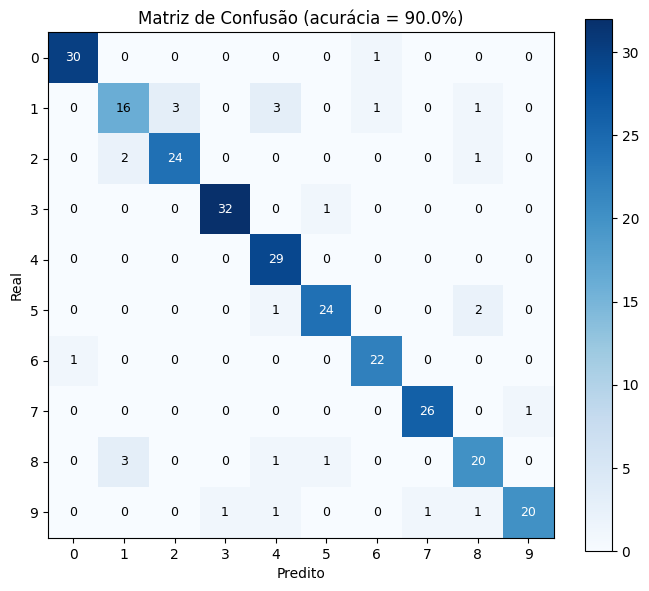

In [15]:
y_pred_classes = MLP_clf.predict_classes(X_test)
y_pred_probs   = MLP_clf.predict(X_test)

acc  = accuracy_score(y_test, y_pred_classes)
ce   = MLP_clf.cross_entropy(y_test, y_pred_probs)

print('=== Avaliação no conjunto de TESTE ===')
print(f'  Acurácia      : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  Cross-Entropy : {ce:.4f}')

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_classes)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusão (acurácia = {acc*100:.1f}%)')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=9)
plt.tight_layout()
plt.show()